# 04 — Advanced Image Generation: Diffusion Models (DDPM)

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the **DDPM noise schedule** (β, α, ᾱ) and implement the **forward process** q(xₜ|x₀)
- Train a **noise-prediction denoiser** — the exact training objective inside Stable Diffusion
- Run the **reverse process**: denoise a corrupted real image step by step, and generate from pure noise
- Understand where **text conditioning** plugs in to make text-to-image systems (concept — running Stable Diffusion itself needs a GPU + model download)

## 🔗 Where this fits

**Builds on:** Course 10 — Units 1 and 3 (GANs and VAEs — diffusion is the third family) and Course 08 (AIAT 122) — Unit 2, since the denoiser here is a CNN.

**Used later in:** Course 10 — Unit 3, lesson 05 and Unit 5, lesson 04, which identify this loop inside Stable Diffusion.

---

## Introduction

**Diffusion models** generate by learning to reverse a gradual noising process:

- **Forward** (fixed, no learning): repeatedly add small Gaussian noise until the image is pure noise. Closed form: xₜ = √ᾱₜ·x₀ + √(1−ᾱₜ)·ε.
- **Reverse** (learned): a network predicts the noise ε in xₜ; stepping t = T…0 with that prediction turns noise back into an image.

Stable Diffusion adds two pieces to this exact core: it diffuses in a **VAE latent space** (example 01's architecture!) for efficiency, and conditions the denoiser on **text embeddings** so a prompt steers the reverse process.

---

## 🌍 Why this lesson exists — what was in the corpus

The loop you are about to implement is the loop that was run over LAION-5B to produce Stable Diffusion. In **December 2023** the Stanford Internet Observatory (David Thiel) reported that LAION-5B contained **3,226 suspected instances of child sexual abuse material, 1,008 of them externally validated** using PhotoDNA. LAION took the dataset offline and later republished a filtered version, Re-LAION-5B, from which 2,236 links had been removed.

Almost nobody who trained on LAION-5B knew what was in it, because at five billion web-scraped image–text pairs nobody had looked. The mechanism in this notebook is neutral; the corpus is not, and the corpus is what ends up in the weights.

**What goes wrong without this:** the forward process is fixed and free — all the learning is in reversing it. Get the schedule wrong (ᾱ not reaching ≈0 at t = T) and you train a network to reverse a process that never destroyed the image. Training loss looks fine; generation from noise silently fails.


PyTorch 2.13.0
alpha_bar at t=0: 0.9999   at t=T: 0.0061  (≈0 → pure noise)


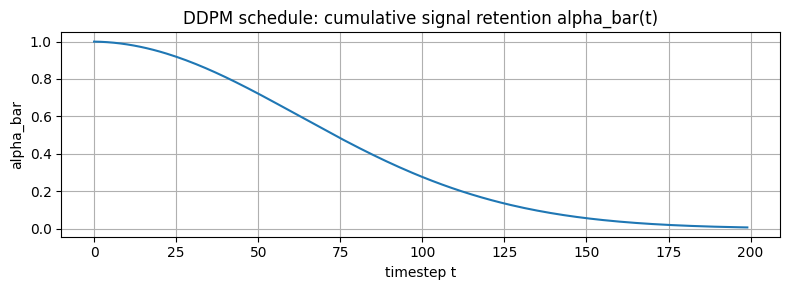

In [1]:
# WHAT/WHY: build the DDPM noise schedule and implement the forward process
# q(x_t | x_0) — then plot how much of the original signal survives at each
# timestep. This schedule drives everything else in the notebook.
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
print(f'PyTorch {torch.__version__}')

torch.manual_seed(0)
T_STEPS = 200
# Compressed linear schedule: real DDPM uses T=1000 with beta up to 0.02; with
# only 200 steps we raise beta_max to 0.05 so alpha_bar still reaches ~0 at T
# (otherwise "t = T" would not be pure noise and sampling could not start there).
betas  = torch.linspace(1e-4, 0.05, T_STEPS)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)     # cumulative signal retention
print(f"alpha_bar at t=0: {alpha_bar[0]:.4f}   at t=T: {alpha_bar[-1]:.4f}  (≈0 → pure noise)")

def q_sample(x0, t, noise=None):
    """Forward process: jump straight to timestep t in closed form."""
    if noise is None:
        noise = torch.randn_like(x0)
    a = alpha_bar[t].view(-1, 1, 1, 1)
    return a.sqrt() * x0 + (1 - a).sqrt() * noise, noise

# ── Plot the schedule (shown inline) ──────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(alpha_bar.numpy())
plt.title("DDPM schedule: cumulative signal retention alpha_bar(t)")
plt.xlabel("timestep t"); plt.ylabel("alpha_bar"); plt.grid(True)
plt.tight_layout(); plt.show()


## Forward Diffusion on Real Images

Watch a real MNIST digit dissolve into noise along the schedule — this is the *data-generating* process the model will learn to reverse.


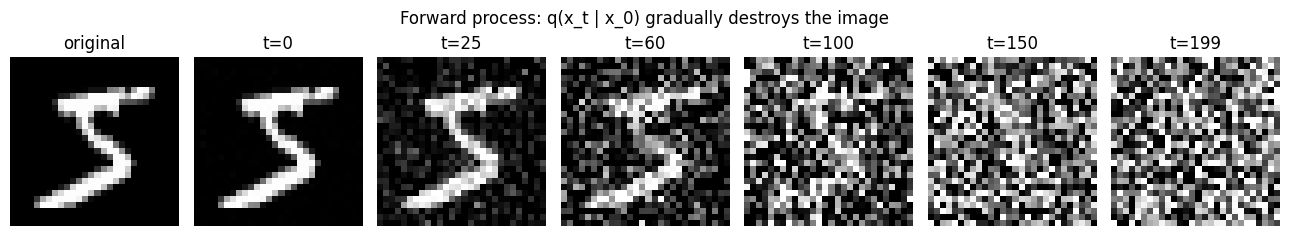

In [2]:
# WHAT/WHY: visualize the forward process on a real digit — the sequence the
# reverse process must learn to undo.
dataset = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=T.ToTensor())
img = dataset[0][0] * 2 - 1          # scale to [-1, 1] (diffusion convention)

timesteps = [0, 25, 60, 100, 150, 199]
fig, axes = plt.subplots(1, len(timesteps) + 1, figsize=(13, 2.4))
axes[0].imshow(img.squeeze(), cmap='gray', vmin=-1, vmax=1)
axes[0].set_title("original"); axes[0].axis('off')
for ax, t in zip(axes[1:], timesteps):
    noisy, _ = q_sample(img.unsqueeze(0), torch.tensor([t]))
    ax.imshow(noisy.squeeze().clamp(-1, 1), cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f"t={t}"); ax.axis('off')
plt.suptitle("Forward process: q(x_t | x_0) gradually destroys the image")
plt.tight_layout(); plt.show()


## Why the Schedule Has to End in Noise

The forward process above only works because ᾱ reaches ≈0 at t = T. The next cell shows what
happens if it does not — the failure the introduction calls *silent*, made visible without
training anything.

ours  (beta_max=0.05): alpha_bar(T) = 0.0061  -> the image enters x_T at 7.8% amplitude
naive (beta_max=0.02): alpha_bar(T) = 0.1322  -> the image enters x_T at 36.4% amplitude

x_T pixel statistics over 256 real digits
  sampling assumes N(0, 1):  mean +0.000   std 1.000
  ours  (beta_max = 0.05):   mean -0.059   std 0.994
  naive (beta_max = 0.02):   mean -0.271   std 0.954   <- not where sampling starts


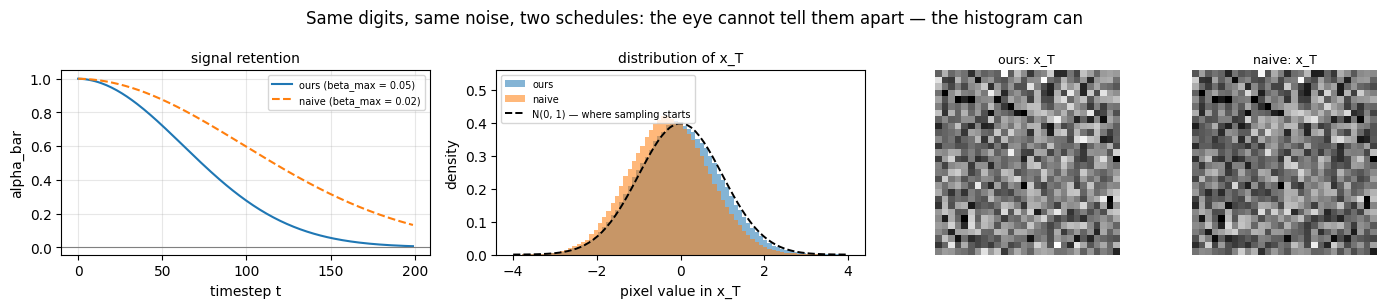

In [3]:
# WHAT/WHY: the introduction warns that a schedule whose alpha_bar does not
# reach ~0 at t=T breaks generation SILENTLY. Cheap to make visible: compare
# our compressed schedule against the naive one (DDPM's beta_max = 0.02 kept at
# only 200 steps) and look at x_T under each — as a picture AND as a
# distribution, because the sampler starts from N(0, 1) and only the
# distribution can tell you whether that is the right place to start.
betas_naive = torch.linspace(1e-4, 0.02, T_STEPS)          # right beta, wrong T
ab_naive    = torch.cumprod(1.0 - betas_naive, dim=0)
print(f"ours  (beta_max=0.05): alpha_bar(T) = {alpha_bar[-1]:.4f}  -> the image enters x_T at {alpha_bar[-1].sqrt():.1%} amplitude")
print(f"naive (beta_max=0.02): alpha_bar(T) = {ab_naive[-1]:.4f}  -> the image enters x_T at {ab_naive[-1].sqrt():.1%} amplitude")

demo_gen = torch.Generator().manual_seed(11)               # own RNG: global stream untouched
batch0   = torch.stack([dataset[i][0] for i in range(256)]) * 2 - 1
eps_b    = torch.randn(batch0.shape, generator=demo_gen)
xT_ours  = alpha_bar[-1].sqrt() * batch0 + (1 - alpha_bar[-1]).sqrt() * eps_b
xT_naive = ab_naive[-1].sqrt()  * batch0 + (1 - ab_naive[-1]).sqrt()  * eps_b

print(f"\nx_T pixel statistics over 256 real digits")
print(f"  sampling assumes N(0, 1):  mean {0.0:+.3f}   std {1.0:.3f}")
print(f"  ours  (beta_max = 0.05):   mean {xT_ours.mean():+.3f}   std {xT_ours.std():.3f}")
print(f"  naive (beta_max = 0.02):   mean {xT_naive.mean():+.3f}   std {xT_naive.std():.3f}   <- not where sampling starts")

fig, ax = plt.subplots(1, 4, figsize=(14, 3.1),
                       gridspec_kw={'width_ratios': [1.35, 1.35, 0.7, 0.7]})

ax[0].plot(alpha_bar.numpy(), label="ours (beta_max = 0.05)")
ax[0].plot(ab_naive.numpy(), '--', label="naive (beta_max = 0.02)")
ax[0].axhline(0, color='gray', lw=.8)
ax[0].set_xlabel("timestep t"); ax[0].set_ylabel("alpha_bar")
ax[0].set_title("signal retention", fontsize=10); ax[0].legend(fontsize=7); ax[0].grid(alpha=.3)

bins = np.linspace(-4, 4, 80)
ax[1].hist(xT_ours.flatten().numpy(),  bins=bins, density=True, alpha=.55, label="ours")
ax[1].hist(xT_naive.flatten().numpy(), bins=bins, density=True, alpha=.55, label="naive")
ax[1].plot(bins, np.exp(-bins**2 / 2) / np.sqrt(2 * np.pi), 'k--', lw=1.4,
           label="N(0, 1) — where sampling starts")
ax[1].set_xlabel("pixel value in x_T"); ax[1].set_ylabel("density")
ax[1].set_title("distribution of x_T", fontsize=10)
ax[1].set_ylim(0, 0.56)                      # headroom: legend clears the peak
ax[1].legend(fontsize=7, loc='upper left')

for a, img, name in ((ax[2], xT_ours[0],  "ours: x_T"),
                     (ax[3], xT_naive[0], "naive: x_T")):
    a.imshow(img.squeeze().clamp(-2.5, 2.5), cmap='gray', vmin=-2.5, vmax=2.5)
    a.set_title(name, fontsize=9); a.axis('off')

plt.suptitle("Same digits, same noise, two schedules: the eye cannot tell them apart — the histogram can")
plt.tight_layout(); plt.show()


### 👁️ Read the figure

**Left.** Our compressed schedule (solid) reaches ᾱ ≈ 0.006 at t = 200. The naive one —
DDPM's β_max = 0.02, correct at T = 1000, kept unchanged at T = 200 — flattens out at 0.132,
so the original image still enters x_T at **36% amplitude**.

**Middle — the panel the title promises.** Both histograms are the pixel values of x_T over
256 real digits, against the dashed N(0, 1) that sampling assumes it is starting from. Ours
(blue) sits on the dashed curve: mean −0.059, standard deviation 0.994. The naive one (orange)
is visibly shifted left and narrower: mean −0.271, standard deviation 0.954. That leftward
shift **is** the leftover digit — MNIST is mostly black, so 36% of a mostly-black image pulls
every pixel down. Sampling would start from N(0, 1) and land in a distribution the model was
never trained on.

**The two images on the right both look like noise.** That is the finding, not a failed demo:
you cannot see the 36% of digit that is still there. This is exactly why the notebook calls
the failure *silent* — neither the picture nor the training loss would ever tell you. Only the
histogram does.

**The middle panel is where it stops being silent.** MNIST backgrounds are −1, and 36% of −1
survives, so under the naive schedule x_T's pixels have mean **−0.271** and the orange
histogram sits left of the black N(0, 1) curve. Ours has mean −0.059 and lies on it. Sampling
always begins at N(0, I): with the naive schedule the reverse process starts in a place the
denoiser never saw at t = T, and generation fails while every number you were watching stays
healthy. Print ᾱ at both ends of your schedule; this figure is why.

## Train the Denoiser (the Stable-Diffusion training loop)

The training loop is three lines of math: pick a random t, noise the image to xₜ, ask the network to predict the noise ε, minimize MSE(ε̂, ε). Our denoiser is a small **convolutional U-Net-style network** with a skip connection and a learned timestep embedding — the same shape of model as Stable Diffusion's U-Net, ~10,000× smaller.


In [4]:
# WHAT/WHY: train a small convolutional noise-prediction network with the
# exact DDPM objective — random t, noise to x_t, predict epsilon, MSE loss.
# ~75 s on CPU for 3 epochs over 25,600 images.
torch.manual_seed(0)
# ── Data: 25,600 MNIST digits, batches of 256 ─────────────────────────────
subset = torch.utils.data.Subset(dataset, range(25_600))
loader = torch.utils.data.DataLoader(subset, batch_size=256, shuffle=True)

class ConvDenoiser(nn.Module):
    """Tiny U-Net-style denoiser: downsample, process, upsample + skip."""
    def __init__(self):
        super().__init__()
        self.emb   = nn.Embedding(T_STEPS, 16)          # learned timestep embedding
        self.tproj = nn.Linear(16, 28 * 28)             # timestep → extra input channel
        self.enc1  = nn.Sequential(nn.Conv2d(2, 32, 3, padding=1), nn.ReLU())
        self.enc2  = nn.Sequential(nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU())  # 28→14
        self.mid   = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.up    = nn.Sequential(nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU())  # 14→28
        self.out   = nn.Conv2d(64, 1, 3, padding=1)     # 64 = up(32) + skip(32)
    def forward(self, x, t):
        tmap = self.tproj(self.emb(t)).view(-1, 1, 28, 28)   # timestep as an image channel
        h1 = self.enc1(torch.cat([x, tmap], dim=1))
        h  = self.up(self.mid(self.enc2(h1)))
        return self.out(torch.cat([h, h1], dim=1))           # skip connection

model = ConvDenoiser()
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
print(f"denoiser parameters: {sum(p.numel() for p in model.parameters()):,}")


# ── Training: each batch gets random timesteps, noised inputs, MSE target ──
for epoch in range(3):
    total = 0.0
    for x, _ in loader:
        x = x * 2 - 1                                        # [-1, 1]
        t = torch.randint(0, T_STEPS, (x.size(0),))          # random timestep per image
        x_t, noise = q_sample(x, t)                          # forward-noise the batch
        loss = F.mse_loss(model(x_t, t), noise)              # predict the noise
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"epoch {epoch+1}/3 — noise-prediction MSE: {total/len(loader):.4f}")
print("This loop IS Stable Diffusion training — scaled down from 860M parameters.")


denoiser parameters: 105,937


epoch 1/3 — noise-prediction MSE: 0.2712


epoch 2/3 — noise-prediction MSE: 0.1229


epoch 3/3 — noise-prediction MSE: 0.0956
This loop IS Stable Diffusion training — scaled down from 860M parameters.


## Is One Training Loss Number Enough?

The loop above printed one MSE per epoch: 0.27, 0.12, 0.096. That is an average over *all*
timesteps, and noise prediction at t = 5 and at t = 195 are not the same job — at t = 195 the
input is almost pure noise, so the noise is almost the whole picture, while at t = 5 the input
is almost the clean digit and the noise is a whisper. Below we measure the trained denoiser
across the schedule on **held-out digits it never trained on**, and plot two errors: the one
the loss function optimises, and the one your eye judges.

    t  alpha_bar  MSE(eps_hat, eps)   MSE(x0_hat, x0)
    4     0.9970              0.367             0.001
   17     0.9606              0.195             0.006
   30     0.8869              0.140             0.013
   43     0.7847              0.111             0.025
   56     0.6651              0.095             0.041
   69     0.5400              0.082             0.062
   82     0.4199              0.070             0.086
   95     0.3127              0.062             0.115
  108     0.2230              0.051             0.155
  121     0.1522              0.041             0.196
  134     0.0995              0.034             0.240
  147     0.0622              0.026             0.282
  160     0.0372              0.023             0.336
  173     0.0213              0.020             0.390
  186     0.0117              0.019             0.489
  199     0.0061              0.020             0.488

do-nothing baselines — noise: 1.000   image: 0.928


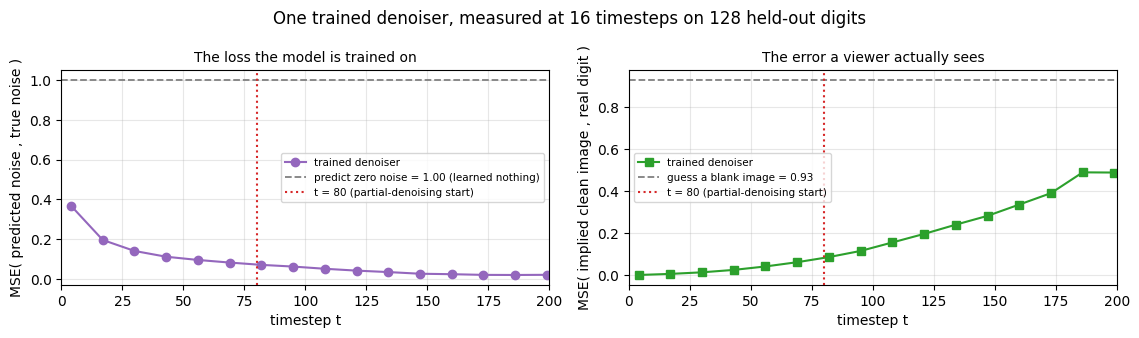

In [5]:
# WHAT/WHY: a single average MSE hides how the denoiser's job changes with t.
# Measure the TRAINED network at 16 timesteps on 128 held-out digits (indices
# 50,000+, outside the 25,600 it trained on) and plot both errors: MSE on the
# noise (the training objective) and MSE on the implied clean image (what a
# viewer sees). This is evaluation only — no extra training.
rng_state = torch.get_rng_state()     # this measurement must not shift the RNG
torch.manual_seed(1234)               # the sampling cells below depend on

held_out = torch.stack([dataset[i][0] for i in range(50_000, 50_128)]) * 2 - 1
ts = torch.linspace(4, T_STEPS - 1, 16).long().tolist()

eps_mse, x0_mse = [], []
with torch.no_grad():
    for t in ts:
        tt = torch.full((len(held_out),), t, dtype=torch.long)
        x_t, noise = q_sample(held_out, tt)          # forward-noise to step t
        eps_hat = model(x_t, tt)                     # the network's prediction
        ab = alpha_bar[t]
        # the clean image implied by that prediction (the same formula sampling uses)
        x0_hat = ((x_t - (1 - ab).sqrt() * eps_hat) / ab.sqrt()).clamp(-1, 1)
        eps_mse.append(F.mse_loss(eps_hat, noise).item())
        x0_mse.append(F.mse_loss(x0_hat, held_out).item())
torch.set_rng_state(rng_state)        # restore: later cells are unaffected

# Two do-nothing baselines to judge the curves against
eps_null = 1.0                                          # "predict zero noise": E[eps^2] = 1
x0_null  = float((held_out ** 2).mean())                # "guess mid-grey" for the image

print(f"{'t':>5} {'alpha_bar':>10} {'MSE(eps_hat, eps)':>18} {'MSE(x0_hat, x0)':>17}")
for t, e, x in zip(ts, eps_mse, x0_mse):
    print(f"{t:>5} {alpha_bar[t]:>10.4f} {e:>18.3f} {x:>17.3f}")
print(f"\ndo-nothing baselines — noise: {eps_null:.3f}   image: {x0_null:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.4))
ax[0].plot(ts, eps_mse, 'o-', color='tab:purple', label="trained denoiser")
ax[0].axhline(eps_null, color='gray', ls='--', lw=1.3,
              label=f"predict zero noise = {eps_null:.2f} (learned nothing)")
ax[0].set_ylabel("MSE( predicted noise , true noise )")
ax[0].set_title("The loss the model is trained on", fontsize=10)

ax[1].plot(ts, x0_mse, 's-', color='tab:green', label="trained denoiser")
ax[1].axhline(x0_null, color='gray', ls='--', lw=1.3,
              label=f"guess a blank image = {x0_null:.2f}")
ax[1].set_ylabel("MSE( implied clean image , real digit )")
ax[1].set_title("The error a viewer actually sees", fontsize=10)

for a in ax:
    a.axvline(80, color='tab:red', ls=':', lw=1.5, label="t = 80 (partial-denoising start)")
    a.set_xlabel("timestep t"); a.set_xlim(0, T_STEPS); a.grid(alpha=0.3)
# legends parked in the empty half of each panel, clear of the curve and the baseline
ax[0].legend(fontsize=7.5, loc='center right')
ax[1].legend(fontsize=7.5, loc='center left')
plt.suptitle("One trained denoiser, measured at 16 timesteps on 128 held-out digits")
plt.tight_layout(); plt.show()

### 👁️ Read the figures

**Left — the training objective gets EASIER as t grows.** The noise-prediction error falls
from 0.367 at t = 4 to 0.020 at t = 199, an 18× drop, and sits far below the do-nothing
baseline of 1.00 everywhere. That is not a paradox: at t = 199 the input is almost entirely
the noise it is being asked to name, so naming it is nearly a copy operation. At t = 4 the
input is almost the clean digit and the noise is a whisper the network can barely hear.

**Right — the error you can see runs the other way.** Turn the same predictions into an
implied clean image and the error climbs from 0.001 at t = 4 to 0.488 at t = 199 — just over
half the blank-image baseline of 0.93. Naming the noise is easy at high t; naming the *digit*
underneath it is not.

**So one averaged training loss cannot tell you how the model is doing.** The 0.096 the loop
printed is dominated by the many high-t steps where the job is easy. It can keep falling while
the part that decides what the picture will be — the high-t end — barely improves. That is the
honest reason the from-scratch samples below are rough while denoising from t = 80 works well:
at t = 80 the digit is already largely determined (x₀ error 0.086), at t = 199 it is not
determined at all.

**One caveat, so the next figure does not look like a contradiction.** The right panel scores
x̂₀ against a *real* held-out digit that really is hidden under the noise. When you generate
from pure noise there is no true digit to be wrong about — the model is free to invent one.
That is why the storyboard two cells below shows x̂₀ committing to a shape early even though
its error against any particular real digit at that t would be large.

## The Reverse Process — Denoising and Generation

Sampling runs the schedule backwards: at each t, estimate x₀ from the predicted noise (clamped to valid pixel range — a standard stabilizer for small models), form the posterior mean, add the step's noise, repeat.

Two experiments, honestly graded:
1. **Partial denoising** (easy): noise a real digit to t=80, reverse back to 0. Our small model handles this well — verified by MSE.
2. **Full generation** (hard): start from pure noise at t=199. Expect *rough digit-like strokes*, not clean digits — this model is ~10,000× smaller and trained ~1,000× less than a production DDPM. The point is that the mechanism works end to end.


MSE vs original — noisy (t=80): 0.668   after reverse process: 0.104


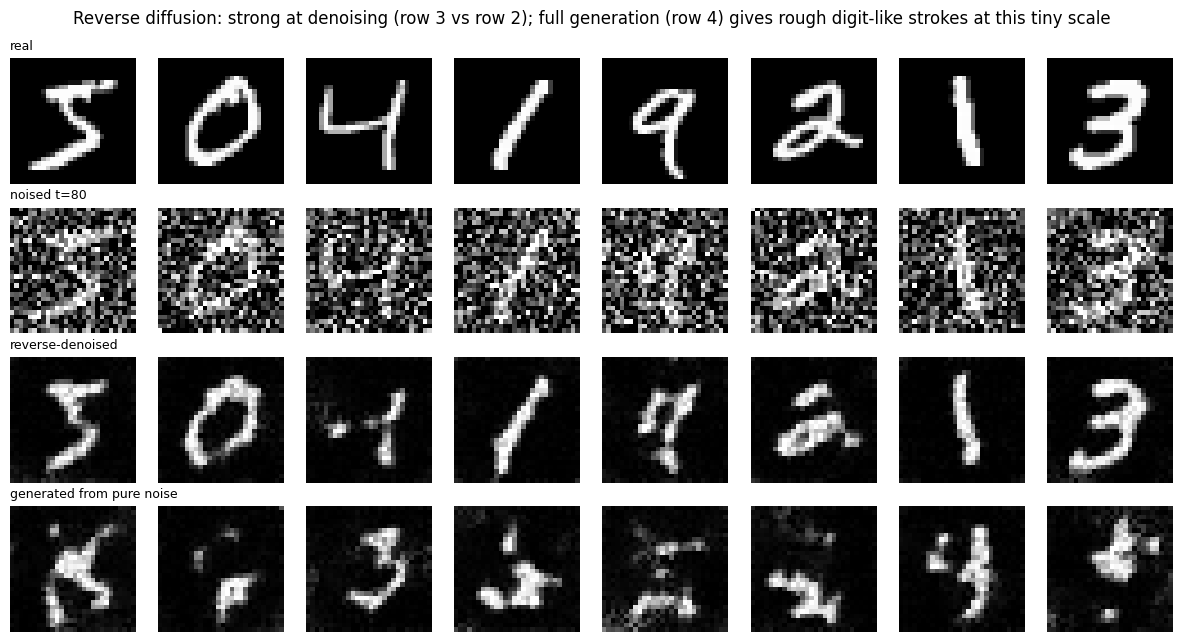


Read it honestly: the reverse process reconstructs noised digits well
(compare the MSEs), while from-scratch samples are rough stroke patterns —
scale of model + training is exactly what separates this from DALL-E.


In [6]:
# WHAT/WHY: implement DDPM reverse sampling (with the x0-clamping stabilizer)
# and run both experiments: partial denoising of real digits (verified by MSE)
# and full generation from pure noise.
@torch.no_grad()
def p_sample_loop(n, start_t=T_STEPS - 1, x=None, trace=None, every=25):
    """Reverse process from timestep start_t down to 0.

    Pass `trace=[]` to also collect (t, x_t, x0_hat) snapshots every `every`
    steps — the raw material for the storyboard two cells below. Collecting
    them costs nothing: they are values the loop already computes.
    """
    if x is None:
        x = torch.randn(n, 1, 28, 28)                  # start from pure noise
    for t in reversed(range(0, start_t + 1)):
        tt  = torch.full((n,), t, dtype=torch.long)
        eps = model(x, tt)                             # predicted noise
        ab  = alpha_bar[t]
        # estimate x0 from the noise prediction, clamped to valid pixel range
        x0_hat = ((x - (1 - ab).sqrt() * eps) / ab.sqrt()).clamp(-1, 1)
        if trace is not None and (t % every == 0 or t == start_t):
            trace.append((t, x.clone(), x0_hat.clone()))
        if t > 0:
            abp   = alpha_bar[t - 1]
            # DDPM posterior mean q(x_{t-1} | x_t, x0_hat), plus its noise
            mean = (abp.sqrt() * betas[t]) / (1 - ab) * x0_hat \
                 + (alphas[t].sqrt() * (1 - abp)) / (1 - ab) * x
            var  = betas[t] * (1 - abp) / (1 - ab)
            x = mean + var.sqrt() * torch.randn_like(x)
        else:
            x = x0_hat
    return x

# ── Experiment 1: partial denoising of real digits from t=80 ──────────────
x_real = torch.stack([dataset[i][0] for i in range(8)]) * 2 - 1
x_noisy, _ = q_sample(x_real, torch.full((8,), 80, dtype=torch.long))
x_denoised = p_sample_loop(8, start_t=80, x=x_noisy.clone())

mse_noisy    = F.mse_loss(x_noisy,    x_real).item()
mse_denoised = F.mse_loss(x_denoised, x_real).item()
print(f"MSE vs original — noisy (t=80): {mse_noisy:.3f}   after reverse process: {mse_denoised:.3f}")

# ── Experiment 2: full generation from pure noise (tracing the path) ──────
gen_trace = []
generated = p_sample_loop(8, trace=gen_trace)

fig, axes = plt.subplots(4, 8, figsize=(12, 6.5))
rows = [(x_real, "real"), (x_noisy, "noised t=80"), (x_denoised, "reverse-denoised"),
        (generated, "generated from pure noise")]
for r, (arr, name) in enumerate(rows):
    for j in range(8):
        axes[r, j].imshow(arr[j, 0].clamp(-1, 1), cmap='gray', vmin=-1, vmax=1)
        axes[r, j].axis('off')
    axes[r, 0].set_title(name, loc='left', fontsize=9)
plt.suptitle("Reverse diffusion: strong at denoising (row 3 vs row 2); full generation (row 4) gives rough digit-like strokes at this tiny scale")
plt.tight_layout(); plt.show()

print("\nRead it honestly: the reverse process reconstructs noised digits well")
print("(compare the MSEs), while from-scratch samples are rough stroke patterns —")
print("scale of model + training is exactly what separates this from DALL-E.")


## The Path, Not Just the Destination

The figure above shows where the reverse process *ended*. Diffusion's whole idea is the
200-step path it took to get there, so below is that path — replayed from snapshots the
sampler recorded as it ran, as a step table, a storyboard, and an animation.

    t  alpha_bar  std(x_t)  std(x0_hat)  signal left in x_t
  199     0.0061     0.989        0.598    7.8%
  175     0.0195     0.985        0.520   14.0%
  150     0.0555     0.974        0.428   23.6%
  125     0.1342     0.959        0.434   36.6%
  100     0.2760     0.921        0.452   52.5%
   75     0.4834     0.838        0.528   69.5%
   50     0.7217     0.738        0.501   85.0%
   25     0.9192     0.595        0.495   95.9%
    0     0.9999     0.470        0.469  100.0%


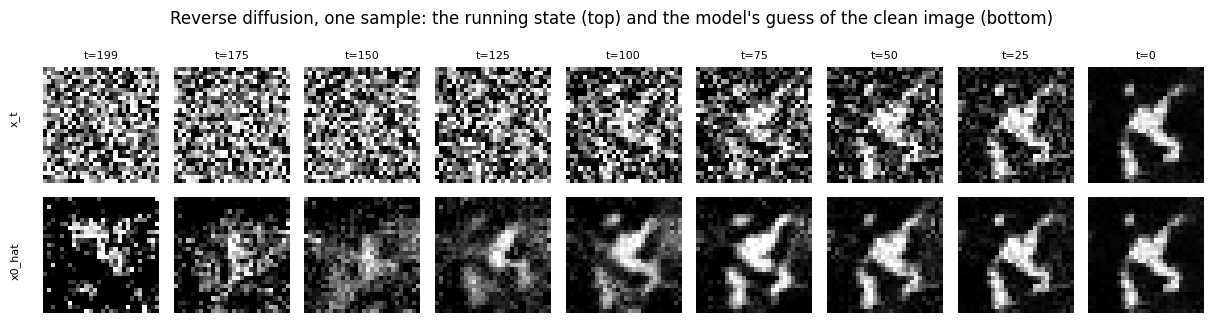

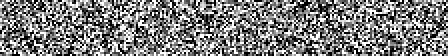

animation: 9 frames from t=199 down to t=0, all eight samples denoising together.


In [7]:
# WHAT/WHY: the row of finished samples above shows the DESTINATION. Diffusion
# is a 200-step journey, and the journey is the lesson — so here is the path the
# generation above actually took, from the snapshots the sampler already
# recorded. Two rows: the running state x_t, and the model's current guess of
# the clean image x0_hat. The GIF helper is the idiom from Course 09's
# course09_step_viz (frames_to_gif_bytes / display_gif), inlined so this
# notebook stands alone.
import io
from PIL import Image
from IPython.display import Image as IPyImage, display

SAMPLE = 0                                   # follow one of the eight samples
steps  = gen_trace[:9]                       # cap the storyboard at 9 snapshots

# ── step table: what is happening numerically at each snapshot ────────────
print(f"{'t':>5} {'alpha_bar':>10} {'std(x_t)':>9} {'std(x0_hat)':>12}  signal left in x_t")
for t, xt, x0h in steps:
    ab = alpha_bar[t].item()
    print(f"{t:>5} {ab:>10.4f} {xt.std():>9.3f} {x0h.std():>12.3f}  {ab**0.5:>6.1%}")

# ── storyboard ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, len(steps), figsize=(1.35 * len(steps), 3.4))
for j, (t, xt, x0h) in enumerate(steps):
    axes[0, j].imshow(xt[SAMPLE, 0].clamp(-1, 1),  cmap='gray', vmin=-1, vmax=1)
    axes[1, j].imshow(x0h[SAMPLE, 0].clamp(-1, 1), cmap='gray', vmin=-1, vmax=1)
    axes[0, j].set_title(f"t={t}", fontsize=8)
    axes[0, j].axis('off'); axes[1, j].axis('off')
fig.text(0.005, 0.66, "x_t",    fontsize=8, rotation=90, va='center')
fig.text(0.005, 0.24, "x0_hat", fontsize=8, rotation=90, va='center')
plt.suptitle("Reverse diffusion, one sample: the running state (top) and the model's guess of the clean image (bottom)")
plt.tight_layout(rect=[0.02, 0, 1, 1]); plt.show()

# ── the same path as an animation, all eight samples per frame ────────────
def frames_to_gif_bytes(frames, duration_ms=420):
    """Encode uint8 frames as one animated GIF (Course 09 course09_step_viz idiom)."""
    imgs = [Image.fromarray(np.asarray(f, dtype=np.uint8)) for f in frames]
    buf = io.BytesIO()
    imgs[0].save(buf, format="GIF", save_all=True, append_images=imgs[1:],
                 duration=duration_ms, loop=0)
    return buf.getvalue()

def display_gif(frames, duration_ms=420):
    display(IPyImage(data=frames_to_gif_bytes(frames, duration_ms), format="gif"))

def tile(batch):                             # [-1,1] batch -> one uint8 strip, 2x scale
    strip = np.concatenate([b[0].clamp(-1, 1).numpy() for b in batch], axis=1)
    return np.kron(((strip + 1) * 127.5).astype(np.uint8), np.ones((2, 2), dtype=np.uint8))

display_gif([tile(xt) for _, xt, _ in gen_trace])
print(f"animation: {len(gen_trace)} frames from t={gen_trace[0][0]} down to "
      f"t={gen_trace[-1][0]}, all eight samples denoising together.")


### 👁️ Read the figures

**Top row — x_t, the state the sampler is actually holding.** At t = 199 it is
indistinguishable from noise, nothing digit-like is visible until around t = 100, and the
strokes only resolve over the last 50 steps. The step table says the same in numbers: ᾱ climbs
0.006 → 0.276 → 0.9999 while std(x_t) falls 0.989 → 0.470 as noise leaves and image arrives.

**Bottom row — x0_hat, the model's guess of the finished image, and the more interesting
row.** The guess is never noise. Even at t = 199 the network commits to a rough layout, and by
t = 125 the shape it will finish with is already recognisable. The remaining 125 steps refine
a composition that was decided in the first quarter of the trajectory — which is why few-step
samplers and distillation work at all, and why the last steps are the cheapest ones to cut.

**Grade the result honestly.** The final image is a digit-*like* stroke pattern, not a clean
digit — the same verdict the sample row above reported. What the storyboard proves is the
*mechanism*: pure noise in, structure out, one small learned step at a time. The gap to a
production generator is model size and training, not this loop.

## 💬 Discuss

1. Partial denoising worked well (**MSE 0.668 → 0.104**) while generation from pure noise gave rough strokes — and both used the *same* trained network. What does that gap tell you about where the difficulty actually lives in a diffusion model?
2. Diffusion needs ~200 sequential network calls to make one image; a GAN needs one. Price a service generating a million images a day both ways. At what quality gap does diffusion stop paying for itself?
3. LAION-5B's contents were unknown to nearly everyone who trained on it. If you fine-tune an open checkpoint for a Saudi client, what do you owe them about provenance — and what can you honestly *verify* rather than merely repeat from a model card?


## Where Text-to-Image Plugs In (concept)

To turn this into Stable Diffusion you add three components — no new mechanism:

1. **VAE latent space** — diffuse over a 64×64×4 latent (example 01's encoder/decoder idea) instead of pixels: ~50× cheaper
2. **Text encoder** (CLIP) — the prompt becomes an embedding vector
3. **Cross-attention in the U-Net** — every denoising step attends to the prompt embedding, so the predicted noise steers xₜ toward images matching the text

Running the real thing needs a GPU and a ~4 GB model download — see `../../DOCS/COLAB_SETUP.md` for the Colab route with the `diffusers` library.


## ⚠️ Where this breaks

**Sampling cost is the defining weakness.** T sequential forward passes per image, none of them parallelisable across timesteps. Latency and price scale with T, which is why the field moved to distillation, consistency models and few-step samplers — and why a GAN is still the right answer when you need one-pass generation at high throughput.

**Diffusion has no encoder.** There is no `encode(x)` that returns a latent for a given image, so the VAE tricks — interpolation between two real images, reconstruction-error anomaly scoring — do not transfer directly. Systems that need them bolt a VAE underneath (which is what latent diffusion does).

**The schedule can break the model silently.** If ᾱ at t = T is not ≈ 0, then x_T is not noise, the reverse process starts from the wrong distribution, and from-scratch generation fails while the training loss looks healthy. Always print ᾱ at both ends, as this notebook does (0.9999 → 0.0061).

**The corpus is the model, and you cannot inspect it afterwards.** Memorised photographs (Carlini et al., 2023, arXiv 2301.13188), unlicensed artwork, and illegal material (Thiel, 2023) are all properties of the weights. Filtering at generation time is a mitigation, not a fix — the only real control is at the data stage, before training.


## 🔭 State of the field (2026)

A 2026 image or video generator still trains a network to undo corruption, but very few of them are
DDPMs in the form you implemented here. Two things changed. The U-Net backbone was replaced by a
transformer, which gave diffusion a clean scaling law (Peebles & Xie, 2022, arXiv 2212.09748); and
the stochastic noise schedule was replaced by **flow matching**, a straight-line velocity field from
noise to data that is simpler to train and far easier to integrate in a handful of steps (Lipman et
al., 2022, arXiv 2210.02747). The T sequential passes you paid for above are now routinely
distilled down to one to four, which is what makes interactive generation affordable (Chen et al.,
2025, arXiv 2511.20549; Zhao et al., 2026, arXiv 2607.03524).

**Why this lesson is still the right thing to learn.** Flow matching changes the *path* between noise
and data, not the idea of learning to move one into the other; few-step distillation is a compression
of the very loop you implemented above. Neither is followable without having first written the forward
closed form, the ε-prediction objective and the reverse sampler by hand. DDPM is also the baseline
every few-step method reports against — and it is what the official plan examines.

## 📚 References & Further Reading

**Papers:**
- Ho et al. (2020) — [DDPM: Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) *(this notebook's math)*
- Rombach et al. (2022) — [Stable Diffusion: Latent Diffusion Models](https://arxiv.org/abs/2112.10752)
- Ho & Salimans (2022) — [Classifier-Free Guidance](https://arxiv.org/abs/2207.12598) *(how prompts are made to steer strongly)*
- Lipman et al. (2022) — [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747) *(the formulation that replaced the stochastic noise schedule in current systems)*
- Peebles & Xie (2022) — [Scalable Diffusion Models with Transformers](https://arxiv.org/abs/2212.09748) *(DiT: the transformer backbone that replaced the U-Net)*
- Chen et al. (2025) — [Flash-DMD: Towards High-Fidelity Few-Step Image Generation with Efficient Distillation and Joint Reinforcement Learning](https://arxiv.org/abs/2511.20549) *(how the T-step loop in this notebook gets compressed to a handful of steps)*
- Zhao et al. (2026) — [Perceptual Flow Matching for Few-Step Generative Modeling](https://arxiv.org/abs/2607.03524) *(few-step image and video generation, supervised in a perceptual feature space)*

**Code:** [Hugging Face `diffusers`](https://github.com/huggingface/diffusers) — production diffusion pipelines


## 📝 Summary

In **04 — Diffusion Models** you implemented the full DDPM loop: the compressed noise schedule (with the honest fix that ᾱ must reach ≈0 at t=T), the closed-form forward process, the noise-prediction training objective on a small conv U-Net, and reverse sampling with x₀-clamping. The results were graded honestly: reverse denoising of real digits works well (printed MSE dropped sharply vs the noisy input), while from-scratch generation at this scale yields rough digit-like strokes — the gap to DALL-E is scale, not mechanism. Text conditioning (concept section) is the only extra ingredient in production text-to-image systems.
